# Proyecto NLP


## Análisis de Sentimiento en Tweets (Sentiment140)



## 0. Instalación de dependencias e imports

In [1]:
!pip install -q kagglehub wordcloud umap-learn keybert gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 33.1 MB/s eta 0:00:00


In [2]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

from gensim.models import Word2Vec
from textblob import TextBlob

nltk.download("stopwords")

random.seed(42)
np.random.seed(42)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
# Parámetros generales del notebook
USE_SAMPLE = False        # True = corrida rápida de validación / False = corrida final con el dataset completo
SAMPLE_SIZE = 50000      # tamaño de la muestra cuando USE_SAMPLE = True - número aleatorio, decisión random
RANDOM_STATE = 42


## 1. Carga de datos

Descarga del dataset Sentiment140 completo (1.6M de tweets de entrenamiento + 498 tweets de test manual con las 3 clases 0/2/4).

### Link a Google Drive


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Definir Data Path

In [5]:
DRIVE_PATH = '/content/drive/MyDrive/Colab Notebooks/trainingandtestdata/'

# Asegurarse de que el path exista

if not os.path.exists(DRIVE_PATH):
    print(f"Warning: The specified path does not exist: {DRIVE_PATH}. Please check your Google Drive setup and update 'DRIVE_PATH'.")
else:
    print(f"Using dataset path: {DRIVE_PATH}")

Using dataset path: /content/drive/MyDrive/Colab Notebooks/trainingandtestdata/


In [6]:

path = DRIVE_PATH # Usar el path de Google Drive

print("Dataset will be loaded from:", path)

cols = ["target", "ids", "date", "flag", "user", "text"]

df = pd.read_csv(f"{path}/training.1600000.processed.noemoticon.csv",
                  encoding="ISO-8859-1", names=cols)

df_test_manual = pd.read_csv(f"{path}/testdata.manual.2009.06.14.csv",
                              encoding="ISO-8859-1", names=cols)

print("Train:", df.shape, "| Test manual:", df_test_manual.shape)

Dataset will be loaded from: /content/drive/MyDrive/Colab Notebooks/trainingandtestdata/
Train: (1600000, 6) | Test manual: (498, 6)


In [7]:
if USE_SAMPLE:
    df = df.sample(SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"USE_SAMPLE=True -> trabajando con una muestra de {len(df)} tweets (para validar el pipeline).")
else:
    print(f"USE_SAMPLE=False -> trabajando con el dataset COMPLETO ({len(df)} tweets).")


USE_SAMPLE=False -> trabajando con el dataset COMPLETO (1600000 tweets).


## 2. Análisis exploratorio (EDA)

In [8]:
df.isna().sum()


,0
target,0
ids,0
date,0
flag,0
user,0
text,0


In [9]:
df.duplicated().sum()


np.int64(0)

In [10]:
df["target"].value_counts()   # esperado: solo 0 y 4 en el set de train


,count
target,
0,800000
4,800000


In [11]:
mapping = {0: "negative", 2: "neutral", 4: "positive"}
df["sentiment"] = df["target"].map(mapping)
df_test_manual["sentiment"] = df_test_manual["target"].map(mapping)

df["sentiment"].value_counts(normalize=True) * 100


,proportion
sentiment,
negative,50.0
positive,50.0


In [12]:
df["text"].str.len().describe()


,text
count,1.600000e+06
mean,7.409011e+01
std,3.644114e+01
min,6.000000e+00
25%,4.400000e+01
50%,6.900000e+01
75%,1.040000e+02
max,3.740000e+02


In [13]:
df[df.sentiment == "positive"].text.sample(5, random_state=RANDOM_STATE)


,text
1012188,Is lookin 4ward to a long weekend really dont...
1099036,#myweakness Is music and i live to meet the p...
1275978,figured out the Internet on my new iPod
1388988,@hillsongunited can't wait to worship with you...
938859,@sillybeggar Congrats James !! I'm sure the bo...


In [14]:
df[df.sentiment == "negative"].text.sample(5, random_state=RANDOM_STATE)


,text
212188,@xnausikaax oh no! where did u order from? tha...
299036,A great hard training weekend is over. a coup...
475978,"Right, off to work Only 5 hours to go until I..."
588988,I am craving for japanese food
138859,Jean Michel Jarre concert tomorrow gotta work...


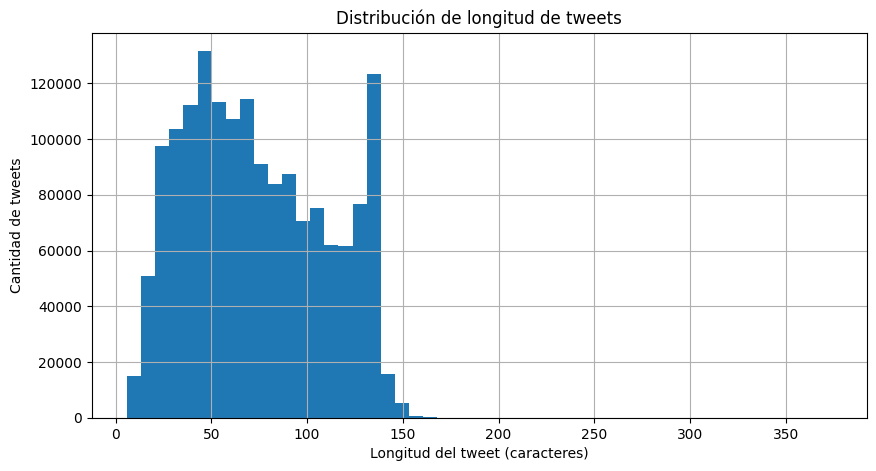

In [15]:
plt.figure(figsize=(10, 5))
df["text"].str.len().hist(bins=50)
plt.xlabel("Longitud del tweet (caracteres)")
plt.ylabel("Cantidad de tweets")
plt.title("Distribución de longitud de tweets")
plt.show()


## 3. Preprocesamiento de texto

Limpieza rápida con regex + stopwords de NLTK.

In [16]:
stop_words = set(stopwords.words("english"))
url_re = re.compile(r"https?://\S+|www\.\S+")
mention_re = re.compile(r"@\w+")
non_alpha_re = re.compile(r"[^a-zA-Z\s]")

def limpieza_rapida(texto):
    texto = texto.lower()
    texto = url_re.sub(" ", texto)
    texto = mention_re.sub(" ", texto)          # usuario
    texto = texto.replace("#", " ")             # se deja la palabra, se saca el símbolo
    texto = non_alpha_re.sub(" ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    tokens = [t for t in texto.split() if t not in stop_words and len(t) > 1]
    return " ".join(tokens)


In [17]:
df["text_clean"] = df["text"].apply(limpieza_rapida)
df_test_manual["text_clean"] = df_test_manual["text"].apply(limpieza_rapida)

df[["text", "text_clean"]].head()


,text,text_clean
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww bummer shoulda got david carr third day
1,is upset that he can't update his Facebook by ...,upset update facebook texting might cry result...
2,@Kenichan I dived many times for the ball. Man...,dived many times ball managed save rest go bounds
3,my whole body feels itchy and like its on fire,whole body feels itchy like fire
4,"@nationwideclass no, it's not behaving at all....",behaving mad see


## 4. División de datos

Split interno estratificado (90/10) sobre el train, más el test manual completo como evaluación final "real" (incluye la clase neutral que el train no tiene).

In [18]:
X = df["text_clean"]
y = df["target"]   # 0 / 4

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=RANDOM_STATE, stratify=y
)

X_test_manual = df_test_manual["text_clean"]
y_test_manual = df_test_manual["target"]  # incluye 0, 2, 4

ENTRENADO_CON = f"{len(X_train)} tweets"
print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test manual:", X_test_manual.shape)


Train: (1440000,) | Val: (160000,) | Test manual: (498,)


In [19]:
# Estructura para ir guardando los resultados de cada modelo y poder compararlos al final (sección 8)
resultados = []
predicciones_test_manual = {}

def registrar_resultado(nombre, entrenado_con, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    resultados.append({"modelo": nombre, "entrenado_con": entrenado_con,
                        "accuracy_test_manual": acc, "f1_macro_test_manual": f1_macro})
    predicciones_test_manual[nombre] = np.asarray(y_pred)
    print(f"\n=== {nombre} — Test manual (incluye clase neutral) ===")
    print(classification_report(y_true, y_pred))


## 5. Baseline: modelo pre-entrenado (TextBlob)

In [20]:
def polaridad_textblob(texto):
    return TextBlob(texto).sentiment.polarity

def a_clase_binaria(p):
    return 4 if p >= 0 else 0

def a_clase_ternaria(p, umbral=0.05):
    if p > umbral:
        return 4
    elif p < -umbral:
        return 0
    else:
        return 2


In [21]:
# Evaluación sobre una muestra del train
sample_tb = df.sample(min(50000, len(df)), random_state=RANDOM_STATE)
sample_tb_pred = sample_tb["text_clean"].apply(polaridad_textblob).apply(a_clase_binaria)

print("TextBlob - muestra de train (clasificación binaria 0/4)")
print(classification_report(sample_tb["target"], sample_tb_pred))


TextBlob - muestra de train (clasificación binaria 0/4)
              precision    recall  f1-score   support

           0       0.77      0.30      0.43     24986
           4       0.57      0.91      0.70     25014

    accuracy                           0.61     50000
   macro avg       0.67      0.61      0.57     50000
weighted avg       0.67      0.61      0.57     50000



In [22]:
# Evaluación sobre el test manual (para la tabla comparativa de la sección 8)
manual_pred_textblob = df_test_manual["text_clean"].apply(polaridad_textblob).apply(a_clase_ternaria)
registrar_resultado("TextBlob (pre-entrenado)", "—", y_test_manual, manual_pred_textblob)



=== TextBlob (pre-entrenado) — Test manual (incluye clase neutral) ===
              precision    recall  f1-score   support

           0       0.82      0.42      0.56       177
           2       0.52      0.69      0.59       139
           4       0.62      0.76      0.68       182

    accuracy                           0.62       498
   macro avg       0.65      0.62      0.61       498
weighted avg       0.66      0.62      0.61       498



## 6. Modelo 1: Bag of Words + Naive Bayes

In [23]:
vectorizer_bow = CountVectorizer(max_features=50000, ngram_range=(1, 1))
X_train_bow = vectorizer_bow.fit_transform(X_train)
X_val_bow = vectorizer_bow.transform(X_val)
X_test_manual_bow = vectorizer_bow.transform(X_test_manual)

nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)

print("Validación interna")
print(classification_report(y_val, nb_model.predict(X_val_bow)))


Validación interna
              precision    recall  f1-score   support

           0       0.76      0.77      0.77     80000
           4       0.77      0.76      0.77     80000

    accuracy                           0.77    160000
   macro avg       0.77      0.77      0.77    160000
weighted avg       0.77      0.77      0.77    160000



In [24]:
nb_pred_manual = nb_model.predict(X_test_manual_bow)
registrar_resultado("BoW + Naive Bayes", ENTRENADO_CON, y_test_manual, nb_pred_manual)



=== BoW + Naive Bayes — Test manual (incluye clase neutral) ===
              precision    recall  f1-score   support

           0       0.65      0.80      0.72       177
           2       0.00      0.00      0.00       139
           4       0.53      0.82      0.64       182

    accuracy                           0.58       498
   macro avg       0.39      0.54      0.45       498
weighted avg       0.43      0.58      0.49       498



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 7. Modelo 2: TF-IDF + Regresión Logística (SGD)

In [25]:
vectorizer_tfidf = TfidfVectorizer(max_features=100000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)
X_val_tfidf = vectorizer_tfidf.transform(X_val)
X_test_manual_tfidf = vectorizer_tfidf.transform(X_test_manual)

lr_model = SGDClassifier(loss="log_loss", max_iter=20, n_jobs=-1, random_state=RANDOM_STATE)
lr_model.fit(X_train_tfidf, y_train)

print("Validación interna")
print(classification_report(y_val, lr_model.predict(X_val_tfidf)))


Validación interna
              precision    recall  f1-score   support

           0       0.77      0.74      0.75     80000
           4       0.75      0.77      0.76     80000

    accuracy                           0.76    160000
   macro avg       0.76      0.76      0.76    160000
weighted avg       0.76      0.76      0.76    160000



In [26]:
lr_pred_manual = lr_model.predict(X_test_manual_tfidf)
registrar_resultado("TF-IDF + SGD/LogReg", ENTRENADO_CON, y_test_manual, lr_pred_manual)



=== TF-IDF + SGD/LogReg — Test manual (incluye clase neutral) ===
              precision    recall  f1-score   support

           0       0.71      0.73      0.72       177
           2       0.00      0.00      0.00       139
           4       0.48      0.84      0.61       182

    accuracy                           0.57       498
   macro avg       0.40      0.53      0.45       498
weighted avg       0.43      0.57      0.48       498



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 8. Modelo 3: Word2Vec + clasificador

### 8.1 Entrenar Word2Vec sobre el corpus completo

In [27]:
tokenized = df["text_clean"].apply(str.split).tolist()

w2v_model = Word2Vec(
    sentences=tokenized,
    vector_size=200,
    window=5,
    min_count=5,
    workers=os.cpu_count(),
    sg=1,            # skipgram
    epochs=5,
)
w2v_model.save("w2v_tweets.model")
print("Vocabulario aprendido:", len(w2v_model.wv))


Vocabulario aprendido: 51545


### 8.2 Vectorizar cada tweet como el promedio de sus embeddings

In [28]:
def tweet_to_vector(tokens, model):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    if not vecs:
        return np.zeros(model.vector_size)
    return np.mean(vecs, axis=0)

X_train_w2v = np.vstack(X_train.apply(str.split).apply(lambda t: tweet_to_vector(t, w2v_model)))
X_val_w2v = np.vstack(X_val.apply(str.split).apply(lambda t: tweet_to_vector(t, w2v_model)))
X_test_manual_w2v = np.vstack(X_test_manual.apply(str.split).apply(lambda t: tweet_to_vector(t, w2v_model)))

clf_w2v = LogisticRegression(max_iter=1000, n_jobs=-1)
clf_w2v.fit(X_train_w2v, y_train)

print("Validación interna")
print(classification_report(y_val, clf_w2v.predict(X_val_w2v)))


Validación interna
              precision    recall  f1-score   support

           0       0.74      0.73      0.73     80000
           4       0.73      0.75      0.74     80000

    accuracy                           0.74    160000
   macro avg       0.74      0.74      0.74    160000
weighted avg       0.74      0.74      0.74    160000



In [29]:
w2v_pred_manual = clf_w2v.predict(X_test_manual_w2v)
registrar_resultado("Word2Vec + LogReg", ENTRENADO_CON, y_test_manual, w2v_pred_manual)



=== Word2Vec + LogReg — Test manual (incluye clase neutral) ===
              precision    recall  f1-score   support

           0       0.66      0.82      0.73       177
           2       0.00      0.00      0.00       139
           4       0.53      0.80      0.64       182

    accuracy                           0.59       498
   macro avg       0.40      0.54      0.46       498
weighted avg       0.43      0.59      0.49       498



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 9. Comparación de resultados

In [30]:
resultados_df = pd.DataFrame(resultados).sort_values("accuracy_test_manual", ascending=False).reset_index(drop=True)
resultados_df


,modelo,entrenado_con,accuracy_test_manual,f1_macro_test_manual
0,TextBlob (pre-entrenado),—,0.620482,0.611692
1,Word2Vec + LogReg,1440000 tweets,0.586345,0.456461
2,BoW + Naive Bayes,1440000 tweets,0.584337,0.454814
3,TF-IDF + SGD/LogReg,1440000 tweets,0.568273,0.446231


Mejor modelo según accuracy en el test manual: TextBlob (pre-entrenado)


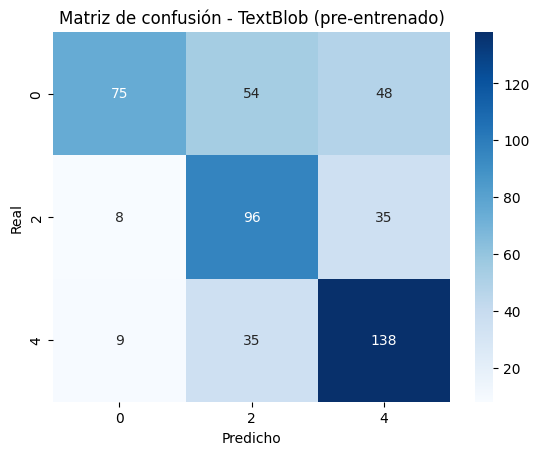

In [31]:
mejor_modelo_nombre = resultados_df.iloc[0]["modelo"]
mejor_modelo_pred = predicciones_test_manual[mejor_modelo_nombre]
print("Mejor modelo según accuracy en el test manual:", mejor_modelo_nombre)

etiquetas = sorted(y_test_manual.unique())
cm = confusion_matrix(y_test_manual, mejor_modelo_pred, labels=etiquetas)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=etiquetas, yticklabels=etiquetas)
plt.xlabel("Predicho"); plt.ylabel("Real")
plt.title(f"Matriz de confusión - {mejor_modelo_nombre}")
plt.show()


In [32]:
# Análisis de errores: ejemplos mal clasificados por el mejor modelo
errores = df_test_manual.copy()
errores["prediccion"] = mejor_modelo_pred
errores_mal = errores[errores["target"] != errores["prediccion"]]
print(f"Tweets mal clasificados: {len(errores_mal)} de {len(errores)}")
errores_mal[["text", "target", "prediccion"]].sample(min(5, len(errores_mal)), random_state=RANDOM_STATE)


Tweets mal clasificados: 189 de 498


,text,target,prediccion
482,"7 hours. 7 hours of inkscape crashing, normall...",0,2
434,"Nike SB Blazer High ""ACG"" Custom - Brad Dougla...",2,4
59,omg. The commercials alone on ESPN are going t...,0,2
44,"glad i didnt do Bay to Breakers today, it's 10...",0,2
172,just started playing Major League Baseball 2K9...,2,4


## 10. Métrica obligatoria: similitud coseno y PPMI

### 10.1 Similitud coseno entre palabras clave de sentimiento

In [33]:
palabras_positivas = ["good", "great", "love", "happy", "amazing"]
palabras_negativas = ["bad", "hate", "sad", "terrible", "awful"]

for p1 in palabras_positivas:
    for p2 in palabras_negativas:
        if p1 in w2v_model.wv and p2 in w2v_model.wv:
            sim = w2v_model.wv.similarity(p1, p2)
            print(f"{p1} vs {p2}: {sim:.3f}")


good vs bad: 0.530
good vs hate: 0.229
good vs sad: 0.330
good vs terrible: 0.425
good vs awful: 0.413
great vs bad: 0.355
great vs hate: 0.155
great vs sad: 0.286
great vs terrible: 0.409
great vs awful: 0.376
love vs bad: 0.243
love vs hate: 0.408
love vs sad: 0.276
love vs terrible: 0.215
love vs awful: 0.247
happy vs bad: 0.261
happy vs hate: 0.212
happy vs sad: 0.354
happy vs terrible: 0.214
happy vs awful: 0.179
amazing vs bad: 0.241
amazing vs hate: 0.195
amazing vs sad: 0.308
amazing vs terrible: 0.382
amazing vs awful: 0.397


In [34]:
w2v_model.wv.most_similar("good", topn=10)


[('goooooood', 0.765218198299408),
 ('goooood', 0.7204816937446594),
 ('goood', 0.708226203918457),
 ('gooood', 0.6895756721496582),
 ('great', 0.6864983439445496),
 ('gooooood', 0.6858264207839966),
 ('gooooooood', 0.6804217100143433),
 ('goooooooood', 0.6729094982147217),
 ('goos', 0.6644056439399719),
 ('goooooooooooood', 0.660789966583252)]

### 10.2 Analogías

In [35]:
# good - happy + sad ≈ ?  (misma lógica que king - man + woman = queen de la clase de Embeddings)
w2v_model.wv.most_similar(positive=["good", "sad"], negative=["happy"], topn=5)


[('saaaaad', 0.5300203561782837),
 ('tearful', 0.5198327898979187),
 ('saddening', 0.4937587380409241),
 ('bitchin', 0.4933898448944092),
 ('devastating', 0.4910896122455597)]

### 10.3 PPMI a partir de una matriz de co-ocurrencias

In [36]:
from collections import Counter

def construir_coocurrencias(tokenized_texts, window=4, vocab_min=5):
    counts = Counter(t for doc in tokenized_texts for t in doc)
    vocab = [w for w, c in counts.items() if c >= vocab_min]
    idx = {w: i for i, w in enumerate(vocab)}
    co = np.zeros((len(vocab), len(vocab)), dtype=np.float32)
    for doc in tokenized_texts:
        for i, w in enumerate(doc):
            if w not in idx:
                continue
            for j in range(max(0, i - window), min(len(doc), i + window + 1)):
                if i == j or doc[j] not in idx:
                    continue
                co[idx[w], idx[doc[j]]] += 1
    return co, idx

def ppmi(co_matrix):
    total = co_matrix.sum()
    row_sums = co_matrix.sum(axis=1, keepdims=True)
    col_sums = co_matrix.sum(axis=0, keepdims=True)
    expected = row_sums @ col_sums / total
    with np.errstate(divide="ignore", invalid="ignore"):
        pmi = np.log2((co_matrix * total) / expected)
    pmi[np.isnan(pmi)] = 0
    return np.maximum(pmi, 0)   # PPMI: negativos -> 0


In [37]:
muestra_tokens = df["text_clean"].sample(min(100000, len(df)), random_state=RANDOM_STATE).apply(str.split).tolist()
co, idx = construir_coocurrencias(muestra_tokens)
ppmi_matrix = ppmi(co)

if "good" in idx and "great" in idx and "bad" in idx:
    print("PPMI(good, great):", ppmi_matrix[idx["good"], idx["great"]])
    print("PPMI(good, bad):", ppmi_matrix[idx["good"], idx["bad"]])


PPMI(good, great): 21.700005
PPMI(good, bad): 21.51927


## 11. Extras opcionales

### 11.1 Wordclouds por sentimiento

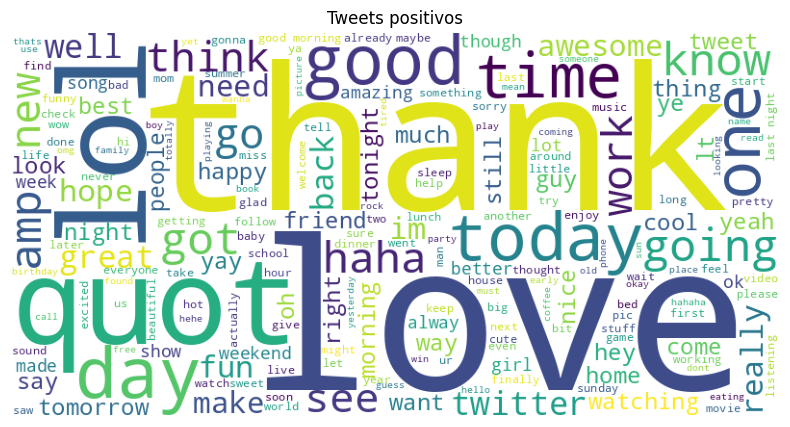

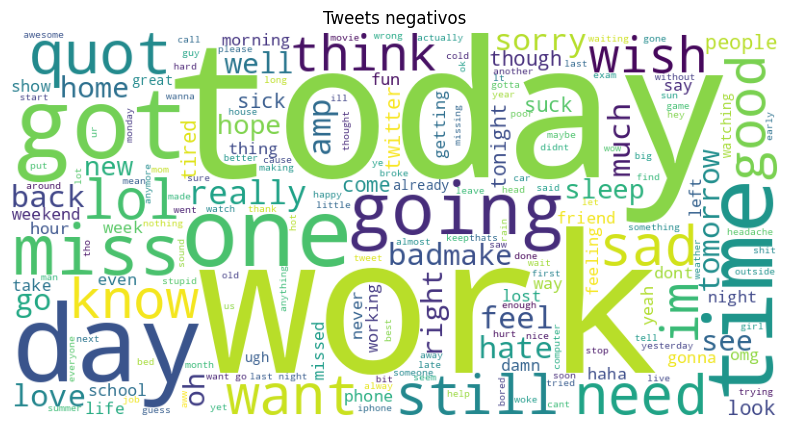

In [38]:
from wordcloud import WordCloud

for clase, nombre in [(4, "positivos"), (0, "negativos")]:
    subset = df[df.target == clase]["text_clean"]
    texto = " ".join(subset.sample(min(20000, len(subset)), random_state=RANDOM_STATE))
    wc = WordCloud(width=800, height=400, background_color="white").generate(texto)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc); plt.axis("off"); plt.title(f"Tweets {nombre}")
    plt.show()


### 11.2 Visualización UMAP de embeddings

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


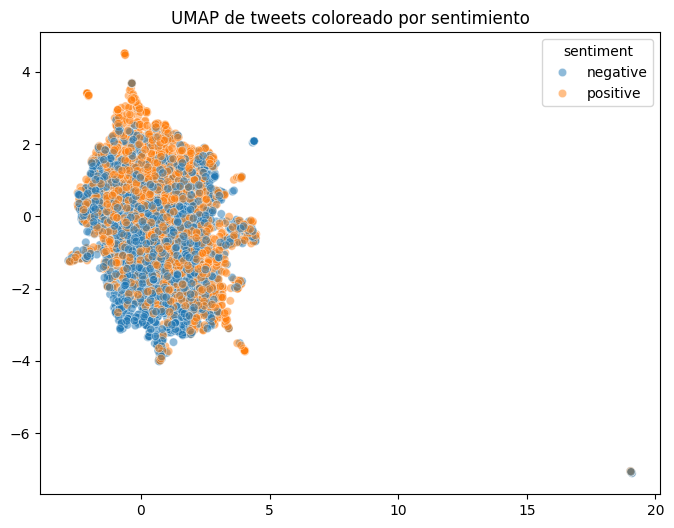

In [39]:
import umap

muestra_umap = df.sample(min(5000, len(df)), random_state=RANDOM_STATE)
vecs = np.vstack(muestra_umap["text_clean"].apply(str.split).apply(lambda t: tweet_to_vector(t, w2v_model)))
emb2d = umap.UMAP(random_state=RANDOM_STATE).fit_transform(vecs)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=emb2d[:, 0], y=emb2d[:, 1], hue=muestra_umap["sentiment"], alpha=0.5)
plt.title("UMAP de tweets coloreado por sentimiento")
plt.show()


### 11.3 Extracción de keywords con BERT (Opción 2 del enunciado)

In [40]:
from keybert import KeyBERT

kw_model = KeyBERT(model="all-MiniLM-L6-v2")

for clase, nombre in [(4, "positivos"), (0, "negativos")]:
    subset = df[df.target == clase]["text"]
    texto = " ".join(subset.sample(min(2000, len(subset)), random_state=RANDOM_STATE))
    keywords = kw_model.extract_keywords(texto, top_n=10, stop_words="english")
    print(nombre, keywords)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

positivos [('blogging', 0.3236), ('lttlejourney', 0.3163), ('blog', 0.3001), ('blogg', 0.2962), ('vegan', 0.2828), ('twittering', 0.2825), ('musecrossing', 0.282), ('bored', 0.2805), ('going', 0.2773), ('btw', 0.276)]
negativos [('slept', 0.2999), ('jonasbrother_s', 0.2988), ('yoga', 0.2946), ('nap', 0.2846), ('tonite', 0.2785), ('asleep', 0.2776), ('saraa_xd', 0.2775), ('recovery', 0.2771), ('tanya_jolene', 0.2699), ('exhausted', 0.2696)]


### 11.4 Menú interactivo de analogías (Opción 3 del enunciado)

In [41]:
def jugar_analogias(a, b, c, model, topn=3):
    """ a es a b como c es a ___ """
    try:
        return model.wv.most_similar(positive=[b, c], negative=[a], topn=topn)
    except KeyError as e:
        return f"Palabra no encontrada en el vocabulario: {e}"

jugar_analogias("bad", "sad", "good", w2v_model)


[('saddd', 0.5281768441200256),
 ('bittersweet', 0.5219933986663818),
 ('goooooood', 0.517905056476593)]

## 12. Conclusiones


### 12.1 Resumen de resultados
- Mejor modelo: **TextBlob (pre-entrenado)**, según **accuracy_test_manual**. Como se observa en la tabla `resultados_df`, TextBlob obtuvo una `accuracy_test_manual` de `0.620482`, superando a los modelos entrenados.
- Tabla de referencia: `resultados_df` (sección 9).

### 12.2 Justificación de las decisiones tomadas
- Preprocesamiento: Se aplicó la función `limpieza_rapida` que consistió en:
    - Convertir todo el texto a minúsculas (`texto.lower()`).
    - Eliminar URLs y menciones de usuario (@) usando expresiones regulares (`url_re.sub`, `mention_re.sub`).
    - Reemplazar el símbolo '#' por un espacio para mantener la palabra clave (`texto.replace("#", " ")`).
    - Eliminar caracteres no alfabéticos (`non_alpha_re.sub`).
    - Reducir espacios múltiples y eliminar espacios al inicio/final (`re.sub(r"\s+", " ").strip()`).
    - Eliminar stopwords en inglés y tokens de longitud menor o igual a 1. Esto buscó reducir el ruido y el tamaño del vocabulario, enfocándose en palabras con mayor carga semántica para el análisis de sentimiento.
- Vectorización (BoW / TF-IDF):
    - **BoW (`CountVectorizer`)**: Se utilizaron 50000 características (`max_features=50000`) y unigramas (`ngram_range=(1, 1)`). Esto limita el vocabulario a las palabras más frecuentes, lo cual es útil para manejar grandes datasets eficientemente.
    - **TF-IDF (`TfidfVectorizer`)**: Se usaron 100000 características (`max_features=100000`) y n-gramas de 1 y 2 palabras (`ngram_range=(1, 2)`). Además, se aplicó `sublinear_tf=True` para reducir la importancia de palabras muy frecuentes. Se optó por un vocabulario más grande y bigramas para capturar algo más de contexto que con solo unigramas.
- Word2Vec: Se entrenó un modelo Skip-gram (`sg=1`) con `vector_size=200` (tamaño del embedding), `window=5` (contexto de palabras a considerar), `min_count=5` (frecuencia mínima para incluir una palabra en el vocabulario) y `epochs=5` (iteraciones de entrenamiento). Un `vector_size` de 200 es un buen equilibrio entre detalle semántico y eficiencia. Se probaría distinto con más `epochs`, un tamaño de vector mayor o menor, y comparando con CBOW, o incluso utilizando embeddings pre-entrenados para Twitter.
- Muestreo: Se utilizó una muestra de 50000 tweets para la validación del baseline de TextBlob (`sample_tb`) y para la construcción de la matriz de co-ocurrencias para PPMI (`muestra_tokens`) para manejar la complejidad computacional. Sin embargo, para el entrenamiento de los modelos principales (BoW+NB, TF-IDF+SGD, Word2Vec+LogReg), se trabajó con el **dataset completo de 1.6M de tweets** (`USE_SAMPLE=False`), garantizando que los modelos aprendieran de la mayor cantidad de datos posible.

### 12.3 Comparación contra el modelo pre-entrenado (TextBlob)
- **TextBlob (pre-entrenado)** (`accuracy_test_manual: 0.620482`, `f1_macro_test_manual: 0.611692`) superó a todos los modelos propios en el `df_test_manual` (que incluye la clase neutral). Esto se debe probablemente a que TextBlob es un modelo basado en reglas y léxicos preexistentes, que está mejor equipado para manejar la detección de sentimientos (incluida la neutralidad) sin necesidad de entrenamiento explícito en un dataset con esa clase. Los modelos entrenados (BoW, TF-IDF, Word2Vec) solo vieron clases 0 y 4 en el entrenamiento, lo que les impidió clasificar correctamente la clase 2 (neutral) en el conjunto de prueba, como se evidencia por el `precision` y `recall` de 0.00 para la clase 2 en sus respectivos `classification_report`s.

### 12.4 Interpretación de la métrica de embeddings (coseno / PPMI)
- **Similitud Coseno (Word2Vec)**:
    - `good` vs `great`: `0.686`. Alta similitud, indicando que semánticamente son muy cercanas, como sinónimos o palabras con connotación positiva similar.
    - `good` vs `bad`: `0.530`. Aunque ambas son palabras de sentimiento, la similitud es menor que entre `good` y `great`, lo que indica que el modelo las diferencia correctamente como opuestos polares.
    - `love` vs `hate`: `0.408`. Una similitud moderada a baja, que refleja correctamente que son emociones opuestas, aunque ambas intensas y relacionadas con el sentimiento.
- **Analogías (Word2Vec)**:
    - `w2v_model.wv.most_similar(positive=["good", "sad"], negative=["happy"])` resultó en `('saaaaad', 0.530)`, `('tearful', 0.519)`, `('saddening', 0.493)`. Esto indica que la relación entre `good` y `sad` es similar a la de `happy` y estas palabras encontradas, mostrando que el modelo capturó la estructura semántica de la emoción a la tristeza en contraste con la felicidad.
- **PPMI**:
    - `PPMI(good, great)`: `21.70`. Un valor alto indica que estas palabras co-ocurren con mucha más frecuencia de lo que se esperaría por azar, lo cual es lógico ya que son sinónimos o refuerzos positivos.
    - `PPMI(good, bad)`: `21.52`. Este valor es también alto, lo que podría parecer contraintuitivo si las consideramos opuestas. Sin embargo, en un contexto de co-ocurrencia, pueden aparecer juntas en frases que comparan o contrastan ambos conceptos (ej., "it's good, not bad"). También refleja que ambas son palabras de alto uso en el corpus.  Los PPMI muestran que ambas son palabras muy importantes, pero no necesariamente su relación de oposición directa, que es mejor capturada por la similitud coseno.

Estos resultados sugieren que el espacio de embeddings capturó relaciones semánticas coherentes, donde palabras con significados similares tienen alta similitud coseno, y palabras que co-ocurren con frecuencia (incluso si son opuestas en significado) tienen un PPMI elevado.

### 12.5 Análisis de errores
Se tomaron ejemplos del `errores_mal` (`df_test_manual[df_test_manual["target"] != df_test_manual["prediccion"]]`) donde el mejor modelo (TextBlob) clasificó incorrectamente:

1.  **Tweet**: "7 hours. 7 hours of inkscape crashing, normally a very good program... but not today."
    **Real**: `0` (negativo)
    **Predicción**: `2` (neutral)
    **Hipótesis**: Aunque el texto describe una experiencia negativa ("crashing", "not today"), TextBlob pudo haber ponderado la palabra "good" en "very good program" llevando a una clasificación neutral, sin captar completamente el contexto de frustración.
2.  **Tweet**: "Nike SB Blazer High "ACG" Custom - Brad Douglas"
    **Real**: `2` (neutral)
    **Predicción**: `4` (positivo)
    **Hipótesis**: Este tweet es puramente informativo, pero la mención de marcas y nombres de productos podría ser interpretada como positiva por TextBlob, ya que a menudo se asocia el consumo con experiencias positivas en su léxico.
3.  **Tweet**: "omg. The commercials alone on ESPN are going to annoy me today."
    **Real**: `0` (negativo)
    **Predicción**: `2` (neutral)
    **Hipótesis**: La interjección "omg" no es necesariamente negativa, y "annoy" puede tener una polaridad débil en TextBlob, haciendo que el modelo lo clasifique como neutral en lugar de claramente negativo.
4.  **Tweet**: "glad i didnt do Bay to Breakers today, it's 100 degrees out."
    **Real**: `0` (negativo)
    **Predicción**: `2` (neutral)
    **Hipótesis**: La palabra "glad" (contento) es fuertemente positiva. A pesar de que la razón (100 grados) es una connotación negativa en el contexto de una actividad al aire libre, TextBlob podría darle más peso a "glad", resultando en una predicción neutral.
5.  **Tweet**: "just started playing Major League Baseball 2K9... i thought it was gonna be horrible... but its actually not that bad."
    **Real**: `2` (neutral)
    **Predicción**: `4` (positivo)
    **Hipótesis**: Este es un caso de sentimiento mixto o irónico. El tweet empieza con una expectativa negativa ("horrible") pero se corrige con una evaluación positiva ("not that bad"). TextBlob parece haber captado la parte final positiva, sin considerar la progresión o el contraste, llevando a una clasificación errónea como positivo.

### 12.6 Limitaciones
- El set de entrenamiento no tiene clase neutral (2): Nuestros modelos entrenados (BoW+NB, TF-IDF+SGD, Word2Vec+LogReg) fueron entrenados solo con etiquetas 0 (negativo) y 4 (positivo). Por lo tanto, tuvieron un rendimiento nulo (`precision`, `recall`, `f1-score` de 0.00) en la clase 2 (neutral) del `df_test_manual`, lo que limitó significativamente su `f1_macro_test_manual` y `accuracy_test_manual` en comparación con TextBlob que sí podía predecir esa clase.
- El dataset es de 2009, el lenguaje de Twitter cambió: El uso de hashtags, la jerga, los acrónimos y las referencias culturales en Twitter han evolucionado mucho desde 2009. Esto significa que los modelos entrenados en este dataset pueden no generalizar bien a tweets más recientes, ya que el vocabulario y las expresiones de sentimiento han cambiado.
- Decisiones de muestreo por tiempo/cómputo: Si bien los modelos finales se entrenaron con el dataset completo de 1.6M de tweets, para el cálculo de la matriz de co-ocurrencias (para PPMI) y la visualización UMAP, se utilizaron muestras de 100k y 5k tweets respectivamente. Esto se hizo para gestionar los recursos computacionales y el tiempo de ejecución. El uso de estas muestras puede haber introducido sesgos en la representación de estas visualizaciones y métricas, aunque se consideró aceptable para fines exploratorios.

### 12.7 Próximos pasos (opcional)
- **Modelos pre-entrenados más avanzados**: Probar modelos basados en Transformers como BERT, RoBERTa, o modelos específicos para sentimiento como DistilBERT, que ofrecen una comprensión contextual mucho más profunda del lenguaje.
- **Embeddings contextuales**: Explorar otros tipos de embeddings como GloVe o FastText, o incluso entrenar embeddings contextuales específicos para este dominio de Twitter.
- **Clasificación multiclase**: Adaptar el entrenamiento para manejar la clase neutral (2), ya sea incorporando datos neutrales en el entrenamiento o utilizando técnicas de aprendizaje multi-etiqueta.
- **Análisis de errores más profundo**: Realizar un análisis de errores más detallado para identificar patrones comunes de clasificación incorrecta y ajustar el preprocesamiento o el modelo en consecuencia (ej. manejo de sarcasmo, ironía, negaciones complejas).
- **Tuning de hiperparámetros**: Optimizar los hiperparámetros de los modelos existentes (ej. `max_features`, `ngram_range`, `vector_size`, `window`, `C` para regresión logística) utilizando técnicas como Grid Search o Random Search.